In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
tickers_map = {
    "RELIANCE": "RELIANCE.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "INFY": "INFY.NS",
    "M&M": "M&M.NS",
    "BHARTIARTL": "BHARTIARTL.NS",
    "HUL": "HINDUNILVR.NS"
}

data = yf.download(list(tickers_map.values()),
                   start="2020-01-01",end = "2026-01-01",
                   auto_adjust=True)

prices = data["Close"].copy()
high = data["High"].copy()
low = data["Low"].copy()
volume = data["Volume"].copy()
rename_dict = {v: k for k, v in tickers_map.items()}

prices = prices.rename(columns=rename_dict)
high = high.rename(columns=rename_dict)
low = low.rename(columns=rename_dict)
volume = volume.rename(columns=rename_dict)

print(prices.columns)
print(prices.columns)
print(high.columns)
print(low.columns)


[*********************100%***********************]  6 of 6 completed

Index(['BHARTIARTL', 'HDFCBANK', 'HUL', 'INFY', 'M&M', 'RELIANCE'], dtype='object', name='Ticker')
Index(['BHARTIARTL', 'HDFCBANK', 'HUL', 'INFY', 'M&M', 'RELIANCE'], dtype='object', name='Ticker')
Index(['BHARTIARTL', 'HDFCBANK', 'HUL', 'INFY', 'M&M', 'RELIANCE'], dtype='object', name='Ticker')
Index(['BHARTIARTL', 'HDFCBANK', 'HUL', 'INFY', 'M&M', 'RELIANCE'], dtype='object', name='Ticker')


In [54]:
#rsi
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))
rsi = prices.apply(compute_rsi)

#momentum
V = np.log(prices.shift(21) / prices.shift(252))

#sma ratio
sma20 = prices.rolling(20).mean()
sma50 = prices.rolling(50).mean()
sma_ratio = sma20 / sma50

#200dayma
sma200 = prices.rolling(200).mean()
price_200 = prices / sma200

#macd histogram
ema12 = prices.ewm(span=12, adjust=False).mean()
ema26 = prices.ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
signal_line = macd_line.ewm(span=9, adjust=False).mean()
macd_hist = macd_line - signal_line

#Adding Technical Indicators
log_ret = np.log(prices / prices.shift(1))
ret_5d = np.log(prices / prices.shift(5))

#20/60dayvolatility
vol_20 = log_ret.rolling(20).std()
vol_60 = log_ret.rolling(60).std()
vol_ratio = vol_20 / vol_60

#atr
tr1 = high - low
tr2 = (high - prices.shift(1)).abs()
tr3 = (low - prices.shift(1)).abs()

true_range = pd.concat([tr1, tr2, tr3], axis=0).groupby(level=0).max()

atr = true_range.rolling(14).mean()


#bollingerbands
sma20 = prices.rolling(20).mean()
std20 = prices.rolling(20).std()
upper = sma20 + 2 * std20
lower = sma20 - 2 * std20
percent_b = (prices - lower) / (upper - lower)

#volumeavg
vol_avg20 = volume.rolling(20).mean()
volume_ratio = volume / vol_avg20
direction = np.sign(prices.diff())
obv = (direction * volume).fillna(0).cumsum()

df = pd.DataFrame()

from functools import reduce

features = {
    "1d_ret": log_ret,
    "5d_ret": ret_5d,
    "RSI": rsi,
    "mom_12_1": mom_12_1,
    "sma20_50_ratio": sma_ratio,
    "price_200dma": price_200,
    "macd_hist": macd_hist,
    "vol_20d": vol_20,
    "vol_ratio": vol_ratio,
    "ATR": atr,
    "bollinger_percent_b": percent_b,
    "volume_20d_ratio": volume_ratio,
    "OBV": obv
}

dfs = []

for name, feature in features.items():
    temp = feature.stack(dropna=False).reset_index()
    temp.columns = ["Date", "Ticker", name]
    dfs.append(temp)
    dup = temp.duplicated(subset=["Date", "Ticker"]).sum()
    print(name, "duplicates:", dup)

df = reduce(lambda left, right:
            pd.merge(left, right, on=["Date", "Ticker"], how="inner"),
            dfs)

df = df.sort_values(["Date", "Ticker"])

1d_ret duplicates: 0
5d_ret duplicates: 0
RSI duplicates: 0
mom_12_1 duplicates: 0
sma20_50_ratio duplicates: 0
price_200dma duplicates: 0
macd_hist duplicates: 0
vol_20d duplicates: 0
vol_ratio duplicates: 0
ATR duplicates: 0
bollinger_percent_b duplicates: 0
volume_20d_ratio duplicates: 0
OBV duplicates: 0


/tmp/ipython-input-3993513781.py:88: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp = feature.stack(dropna=False).reset_index()
/tmp/ipython-input-3993513781.py:88: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp = feature.stack(dropna=False).reset_index()
/tmp/ipython-input-3993513781.py:88: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp = feature.st

In [ ]:
df.head()

,Date,Ticker,1d_ret,5d_ret,RSI,mom_12_1,sma20_50_ratio,price_200dma,macd_hist,vol_20d,vol_ratio,ATR,bollinger_percent_b,volume_20d_ratio,OBV
0,2020-01-01,BHARTIARTL,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
1,2020-01-01,HDFCBANK,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
2,2020-01-01,HUL,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
3,2020-01-01,INFY,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
4,2020-01-01,M&M,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0


fundamental data

In [5]:
def process_fundamental(file_path, ticker_name):

    fund_df = pd.read_excel(file_path)
    fund_df.columns = fund_df.columns.str.strip()

    fund_df = fund_df.rename(columns={
        "DATE": "Date",
        "revenue": "revenue",
        "Operating Profit": "op_profit",
        "Interest": "interest",
        "Net Profit": "net_profit",
        "Equity share capital": "equity",
        "Reserves Exclui,rrding Revaluation Reserves": "reserves",
        "Total Debt": "debt",
        "Cash and Bank Balance": "cash",
        "Total Assets": "assets",
        "Depreciation": "depr"
    })

    fund_df["Date"] = pd.to_datetime(fund_df["Date"], dayfirst=True)
    fund_df = fund_df.sort_values("Date").reset_index(drop=True)

    fund_df["Ticker"] = ticker_name

    fund_df["networth"] = fund_df["equity"] + fund_df["reserves"]
    fund_df["ebitda"] = fund_df["op_profit"] + fund_df["depr"]

    fund_df["rev_ttm"] = fund_df["revenue"].rolling(4).sum()
    fund_df["op_ttm"] = fund_df["op_profit"].rolling(4).sum()
    fund_df["np_ttm"] = fund_df["net_profit"].rolling(4).sum()
    fund_df["int_ttm"] = fund_df["interest"].rolling(4).sum()
    fund_df["ebitda_ttm"] = fund_df["ebitda"].rolling(4).sum()

    # Profitability
    fund_df["op_margin"] = fund_df["op_ttm"] / fund_df["rev_ttm"]
    fund_df["net_margin"] = fund_df["np_ttm"] / fund_df["rev_ttm"]
    fund_df["roe"] = fund_df["np_ttm"] / fund_df["networth"]
    fund_df["roa"] = fund_df["np_ttm"] / fund_df["assets"]

    # Growth
    fund_df["rev_yoy"] = fund_df["revenue"].pct_change(4)
    fund_df["np_yoy"] = fund_df["net_profit"].pct_change(4)
    fund_df["ebitda_yoy"] = fund_df["ebitda"].pct_change(4)

    # Leverage
    fund_df["de_ratio"] = fund_df["debt"] / fund_df["networth"]
    fund_df["int_cov"] = fund_df["op_ttm"] / fund_df["int_ttm"]
    fund_df["net_debt_ebitda"] = (fund_df["debt"] - fund_df["cash"]) / fund_df["ebitda_ttm"]

    return fund_df

fundamental_files = {
    "BHARTIARTL": "bhartiairtel.xlsx",
    "HDFCBANK": "hdfcbank.xlsx",
    "HUL": "hul.xlsx",
    "M&M": "m&m.xlsx",
    "INFY": "infosys.xlsx",
    "RELIANCE": "reliance.xlsx"
}

all_fundamentals = []

for ticker, file in fundamental_files.items():
    temp_df = process_fundamental(file, ticker)
    all_fundamentals.append(temp_df)

fund_df = pd.concat(all_fundamentals, ignore_index=True)

df["Date"] = pd.to_datetime(df["Date"])

df = df.loc[:, ~df.columns.str.endswith(('_x', '_y'))]

cols_to_drop = [
    'op_margin','net_margin','roe','roa',
    'rev_yoy','np_yoy','ebitda_yoy',
    'de_ratio','int_cov','net_debt_ebitda'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df = df[df["Date"].notna()]
fund_df = fund_df[fund_df["Date"].notna()]

df = df.sort_values(["Date","Ticker"]).reset_index(drop=True)
fund_df = fund_df.sort_values(["Date","Ticker"]).reset_index(drop=True)

df = pd.merge_asof(
    df,
    fund_df[[
        "Date","Ticker",
        "op_margin","net_margin","roe","roa",
        "rev_yoy","np_yoy","ebitda_yoy",
        "de_ratio","int_cov","net_debt_ebitda"
    ]],
    on="Date",
    by="Ticker",
    direction="backward"
)

df = df.sort_values(["Ticker","Date"]).reset_index(drop=True)

fund_cols = [
    "op_margin","net_margin","roe","roa",
    "rev_yoy","np_yoy","ebitda_yoy",
    "de_ratio","int_cov","net_debt_ebitda"
]

df[fund_cols] = df.groupby("Ticker")[fund_cols].ffill()

/tmp/ipython-input-3823944381.py:58: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fund_df["rev_yoy"] = fund_df["revenue"].pct_change(4)
/tmp/ipython-input-3823944381.py:59: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fund_df["np_yoy"] = fund_df["net_profit"].pct_change(4)


In [ ]:
df.head()

,Date,Ticker,1d_ret,5d_ret,RSI,mom_12_1,sma20_50_ratio,price_200dma,macd_hist,vol_20d,...,op_margin,net_margin,roe,roa,rev_yoy,np_yoy,ebitda_yoy,de_ratio,int_cov,net_debt_ebitda
0,2020-01-01,BHARTIARTL,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,BHARTIARTL,0.004183,NaN,NaN,NaN,NaN,NaN,0.115907,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,BHARTIARTL,-0.000220,NaN,NaN,NaN,NaN,NaN,0.176115,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-06,BHARTIARTL,-0.012048,NaN,NaN,NaN,NaN,NaN,-0.128519,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-07,BHARTIARTL,-0.010170,NaN,NaN,NaN,NaN,NaN,-0.590661,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import pandas as pd
fund_df = pd.read_excel("bhartiairtel.xlsx")
fund_df.columns = fund_df.columns.str.strip()

fund_df = fund_df.rename(columns={
    "DATE": "Date",
    "revenue": "revenue",
    "Operating Profit": "op_profit",
    "Interest": "interest",
    "Net Profit": "net_profit",
    "Equity share capital": "equity",
    "Reserves Exclui,rrding Revaluation Reserves": "reserves",
    "Total Debt": "debt",
    "Cash and Bank Balance": "cash",
    "Total Assets": "assets",
    "Depreciation": "depr"
})

fund_df["Date"] = pd.to_datetime(fund_df["Date"], dayfirst=True)
fund_df = fund_df.sort_values("Date").reset_index(drop=True)

fund_df["Ticker"] = "BHARTIARTL"

fund_df["networth"] = fund_df["equity"] + fund_df["reserves"]
fund_df["ebitda"] = fund_df["op_profit"] + fund_df["depr"]


fund_df["rev_ttm"] = fund_df["revenue"].rolling(4).sum()
fund_df["op_ttm"] = fund_df["op_profit"].rolling(4).sum()
fund_df["np_ttm"] = fund_df["net_profit"].rolling(4).sum()
fund_df["int_ttm"] = fund_df["interest"].rolling(4).sum()
fund_df["ebitda_ttm"] = fund_df["ebitda"].rolling(4).sum()


# Profitability
fund_df["op_margin"] = fund_df["op_ttm"] / fund_df["rev_ttm"]
fund_df["net_margin"] = fund_df["np_ttm"] / fund_df["rev_ttm"]
fund_df["roe"] = fund_df["np_ttm"] / fund_df["networth"]
fund_df["roa"] = fund_df["np_ttm"] / fund_df["assets"]

# Growth
fund_df["rev_yoy"] = fund_df["revenue"].pct_change(4)
fund_df["np_yoy"] = fund_df["net_profit"].pct_change(4)
fund_df["ebitda_yoy"] = fund_df["ebitda"].pct_change(4)

# Leverage
fund_df["de_ratio"] = fund_df["debt"] / fund_df["networth"]
fund_df["int_cov"] = fund_df["op_ttm"] / fund_df["int_ttm"]
fund_df["net_debt_ebitda"] = (fund_df["debt"] - fund_df["cash"]) / fund_df["ebitda_ttm"]



df["Date"] = pd.to_datetime(df["Date"])


df = df.loc[:, ~df.columns.str.endswith(('_x', '_y'))]

cols_to_drop = [
    'op_margin','net_margin','roe','roa',
    'rev_yoy','np_yoy','ebitda_yoy',
    'de_ratio','int_cov','net_debt_ebitda'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df = df[df["Date"].notna()]
fund_df = fund_df[fund_df["Date"].notna()]



df = df.sort_values(["Date","Ticker"]).reset_index(drop=True)
fund_df = fund_df.sort_values(["Date","Ticker"]).reset_index(drop=True)

df = pd.merge_asof(
    df,
    fund_df[[
        "Date","Ticker",
        "op_margin","net_margin","roe","roa",
        "rev_yoy","np_yoy","ebitda_yoy",
        "de_ratio","int_cov","net_debt_ebitda"
    ]],
    on="Date",
    by="Ticker",
    direction="backward"
)

df = df.sort_values(["Ticker","Date"]).reset_index(drop=True)

fund_cols = [
    "op_margin","net_margin","roe","roa",
    "rev_yoy","np_yoy","ebitda_yoy",
    "de_ratio","int_cov","net_debt_ebitda"
]

df[fund_cols] = df.groupby("Ticker")[fund_cols].ffill()

In [7]:
df = df[df["Date"] >= "2021-01-01"]

In [ ]:
df.isna().sum()


,0
Date,0
Ticker,0
1d_ret,0
5d_ret,0
RSI,0
mom_12_1,6
sma20_50_ratio,0
price_200dma,0
macd_hist,0
vol_20d,0


In [8]:

repo = pd.read_excel("repo.xlsx")
cpi = pd.read_excel("cpi.xlsx")
gsec = pd.read_excel("gsec.xlsx")
repo["Date"] = pd.to_datetime(repo["Date"])
cpi["Date"] = pd.to_datetime(cpi["Date"])
gsec["Date"] = pd.to_datetime(gsec["Date"])
repo = repo.sort_values("Date")
cpi = cpi.sort_values("Date")
gsec = gsec.sort_values("Date")
macro_monthly = repo.merge(cpi, on="Date", how="outer")
macro_monthly = macro_monthly.merge(gsec, on="Date", how="outer")

macro_monthly = macro_monthly.sort_values("Date")
df = df.sort_values("Date")

macro_monthly = macro_monthly.sort_values("Date")
macro_cols = ["repo_rate", "cpi_yoy", "gsec_10y"]

df = df.drop(columns=[col for col in macro_cols if col in df.columns])
df = pd.merge_asof(
    df.sort_values("Date"),
    macro_monthly.sort_values("Date"),
    on="Date",
    direction="backward"
)

In [9]:
import pandas as pd
import numpy as np
import yfinance as yf



tickers = {
    "crude": "BZ=F",
    "nifty": "^NSEI",
    "vix": "^INDIAVIX",
    "sp500": "^GSPC",
    "us10y": "^TNX",
    "usd": "INR=X"
}

start = "2019-01-01"
end   = "2025-12-31"

macro_list = []

for name, ticker_symbol in tickers.items():
    temp = yf.download(ticker_symbol, start=start, end=end, auto_adjust=True)
    temp = temp[["Close"]]
    temp.columns = [name]
    macro_list.append(temp)

macro = pd.concat(macro_list, axis=1)
macro.index.name = "Date"
macro = macro.reset_index()

macro["nifty_log_ret"] = np.log(macro["nifty"] / macro["nifty"].shift(1))
macro["sp500_log_ret"] = np.log(macro["sp500"] / macro["sp500"].shift(1))
macro["crude_log_ret"] = np.log(macro["crude"] / macro["crude"].shift(1))
macro["usd_log_ret"]   = np.log(macro["usd"] / macro["usd"].shift(1))

# US 10Y change (TNX is yield ×10)
macro["us10y"] = macro["us10y"] / 10
macro["us10y_change"] = macro["us10y"].diff()

# VIX log change
macro["vix_log_change"] = np.log(macro["vix"] / macro["vix"].shift(1))

macro = macro[[
    "Date",
    "nifty_log_ret",
    "sp500_log_ret",
    "crude_log_ret",
    "usd_log_ret",
    "us10y_change",
    "vix_log_change"
]]



df = df.loc[:, ~df.columns.str.endswith(('_x', '_y'))]

df["Date"] = pd.to_datetime(df["Date"])
macro["Date"] = pd.to_datetime(macro["Date"])

df = df.sort_values("Date")
macro = macro.sort_values("Date")


macro_cols = [
    "nifty_log_ret",
    "sp500_log_ret",
    "crude_log_ret",
    "usd_log_ret",
    "us10y_change",
    "vix_log_change"
]

df = df.drop(columns=[col for col in macro_cols if col in df.columns], errors='ignore')

df = pd.merge_asof(
    df,
    macro,
    on="Date",
    direction="backward"
)
df[macro_cols] = df[macro_cols].fillna(0)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Global macro features merged successfully ✅


sentiment analysis

In [10]:
!pip install pygooglenews transformers torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.2 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=d0f6248e98dd5d47011bf0f86e8c20485288e993e542a5be65b8b471b4ba089c
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


In [13]:
from pygooglenews import GoogleNews
import pandas as pd
from datetime import datetime, timedelta

gn = GoogleNews(lang='en', country='IN')

def fetch_daily_news(ticker, target_date):
    date_obj = pd.to_datetime(target_date)
    next_day = date_obj + timedelta(days=1)
    query = f"{ticker} share price"

    search = gn.search(query, from_=date_obj.strftime('%Y-%m-%d'), to_=next_day.strftime('%Y-%m-%d'))

    headlines = [item.title for item in search['entries']]
    return headlines
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

def get_sentiment_score(headlines):
    if not headlines:
        return 0.0

    inputs = tokenizer(headlines, padding=True, truncation=True, return_tensors='pt')

    with torch.no_grad():
        outputs = model(**inputs)

    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

    mean_scores = predictions.mean(dim=0)
    score = mean_scores[0].item() - mean_scores[1].item()
    return score
sentiment_data = []

unique_combinations = df[['Date', 'Ticker']].drop_duplicates()

for index, row in unique_combinations.iterrows():
    print(f"Processing {row['Ticker']} for {row['Date']}...")
    headlines = fetch_daily_news(row['Ticker'], row['Date'])
    score = get_sentiment_score(headlines)
    sentiment_data.append({
        'Date': row['Date'],
        'Ticker': row['Ticker'],
        'sentiment_score': score
    })
sent_df = pd.DataFrame(sentiment_data)
df = pd.merge(df, sent_df, on=['Date', 'Ticker'], how='left')
df['sentiment_score'] = df['sentiment_score'].fillna(0)
df.to_csv('final_data.csv', index=False)#created a file named final_data.csv and stored the sentiment scores there so that i dont need to compute sentiment analysis again
print(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Streaming output truncated to the last 5000 lines.
Processing HUL for 2022-08-24 00:00:00...
Processing INFY for 2022-08-24 00:00:00...
Processing M&M for 2022-08-24 00:00:00...
Processing BHARTIARTL for 2022-08-25 00:00:00...
Processing HDFCBANK for 2022-08-25 00:00:00...
Processing RELIANCE for 2022-08-25 00:00:00...
Processing M&M for 2022-08-25 00:00:00...
Processing INFY for 2022-08-25 00:00:00...
Processing HUL for 2022-08-25 00:00:00...
Processing HDFCBANK for 2022-08-26 00:00:00...
Processing M&M for 2022-08-26 00:00:00...
Processing HUL for 2022-08-26 00:00:00...
Processing BHARTIARTL for 2022-08-26 00:00:00...
Processing RELIANCE for 2022-08-26 00:00:00...
Processing INFY for 2022-08-26 00:00:00...
Processing M&M for 2022-08-29 00:00:00...
Processing RELIANCE for 2022-08-29 00:00:00...
Processing HUL for 2022-08-29 00:00:00...
Processing INFY for 2022-08-29 00:00:00...
Processing BHARTIARTL for 2022-08-29 00:00:00...
Processing HDFCBANK for 2022-08-29 00:00:00...
Processing I

In [16]:
df.isna().sum()

,0
Date,0
Ticker,0
1d_ret,0
5d_ret,0
RSI,0
mom_12_1,6
sma20_50_ratio,0
price_200dma,0
macd_hist,0
vol_20d,0


In [18]:
df.columns

Index(['Date', 'Ticker', '1d_ret', '5d_ret', 'RSI', 'mom_12_1',
       'sma20_50_ratio', 'price_200dma', 'macd_hist', 'vol_20d', 'vol_ratio',
       'ATR', 'bollinger_percent_b', 'volume_20d_ratio', 'OBV', 'op_margin',
       'net_margin', 'roe', 'roa', 'rev_yoy', 'np_yoy', 'ebitda_yoy',
       'de_ratio', 'int_cov', 'net_debt_ebitda', 'repo_rate', 'cpi_yoy',
       'gsec_10y', 'nifty_log_ret', 'sp500_log_ret', 'crude_log_ret',
       'usd_log_ret', 'us10y_change', 'vix_log_change', 'sentiment_score'],
      dtype='object')

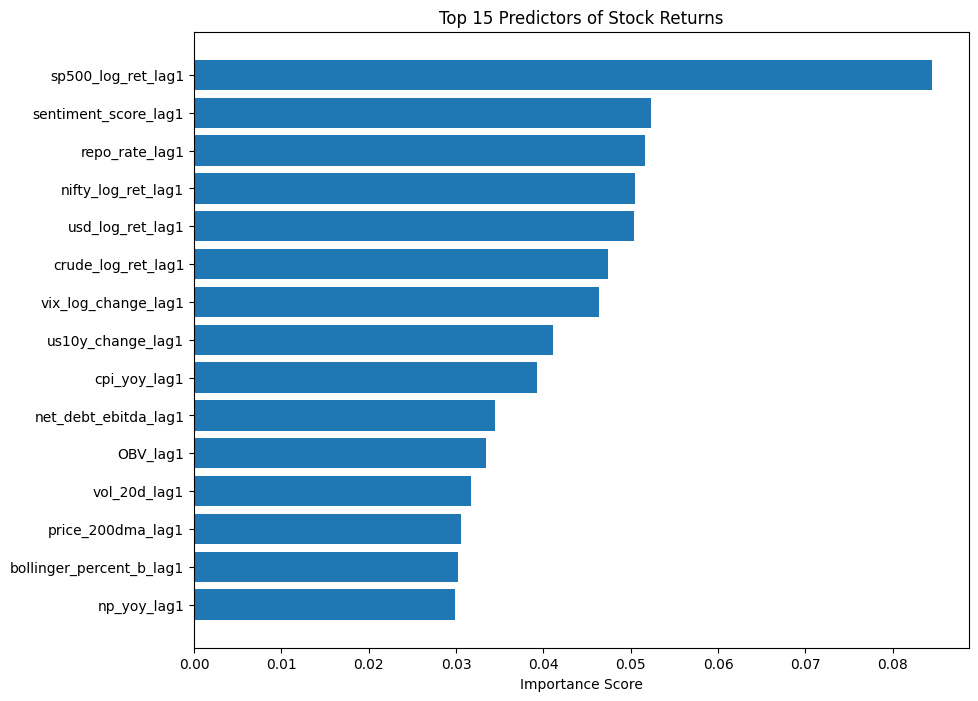

Model Training Complete. Check the chart to see where 'sentiment_score' ranks!


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


df = pd.read_csv('final_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date'])
df['target'] = df.groupby('Ticker')['1d_ret'].shift(-1)
features = [
    '1d_ret', '5d_ret', 'RSI', 'mom_12_1', 'sma20_50_ratio', 'price_200dma',
    'macd_hist', 'vol_20d', 'vol_ratio', 'ATR', 'bollinger_percent_b',
    'volume_20d_ratio', 'OBV', 'op_margin', 'net_margin', 'roe', 'roa',
    'rev_yoy', 'np_yoy', 'ebitda_yoy', 'de_ratio', 'int_cov', 'net_debt_ebitda',
    'repo_rate', 'cpi_yoy', 'gsec_10y', 'nifty_log_ret', 'sp500_log_ret',
    'crude_log_ret', 'usd_log_ret', 'us10y_change', 'vix_log_change', 'sentiment_score'
]

for col in features:
    df[f'{col}_lag1'] = df.groupby('Ticker')[col].shift(0)

df_model = df.dropna(subset=['target'])
df_model = df_model.fillna(0)
train_date = df_model['Date'].max() - pd.Timedelta(days=180)
train = df_model[df_model['Date'] < train_date]
test = df_model[df_model['Date'] >= train_date]

X_train = train[[f'{c}_lag1' for c in features]]
y_train = train['target']
X_test = test[[f'{c}_lag1' for c in features]]
y_test = test['target']

#  SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  TRAIN THE MODEL (XGBoost)
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
model.fit(X_train_scaled, y_train)

# FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
plt.barh(importance['Feature'].head(15), importance['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title('Top 15 Predictors of Stock Returns')
plt.xlabel('Importance Score')
plt.show()

print("Model Training Complete. Check the chart to see where 'sentiment_score' ranks!")

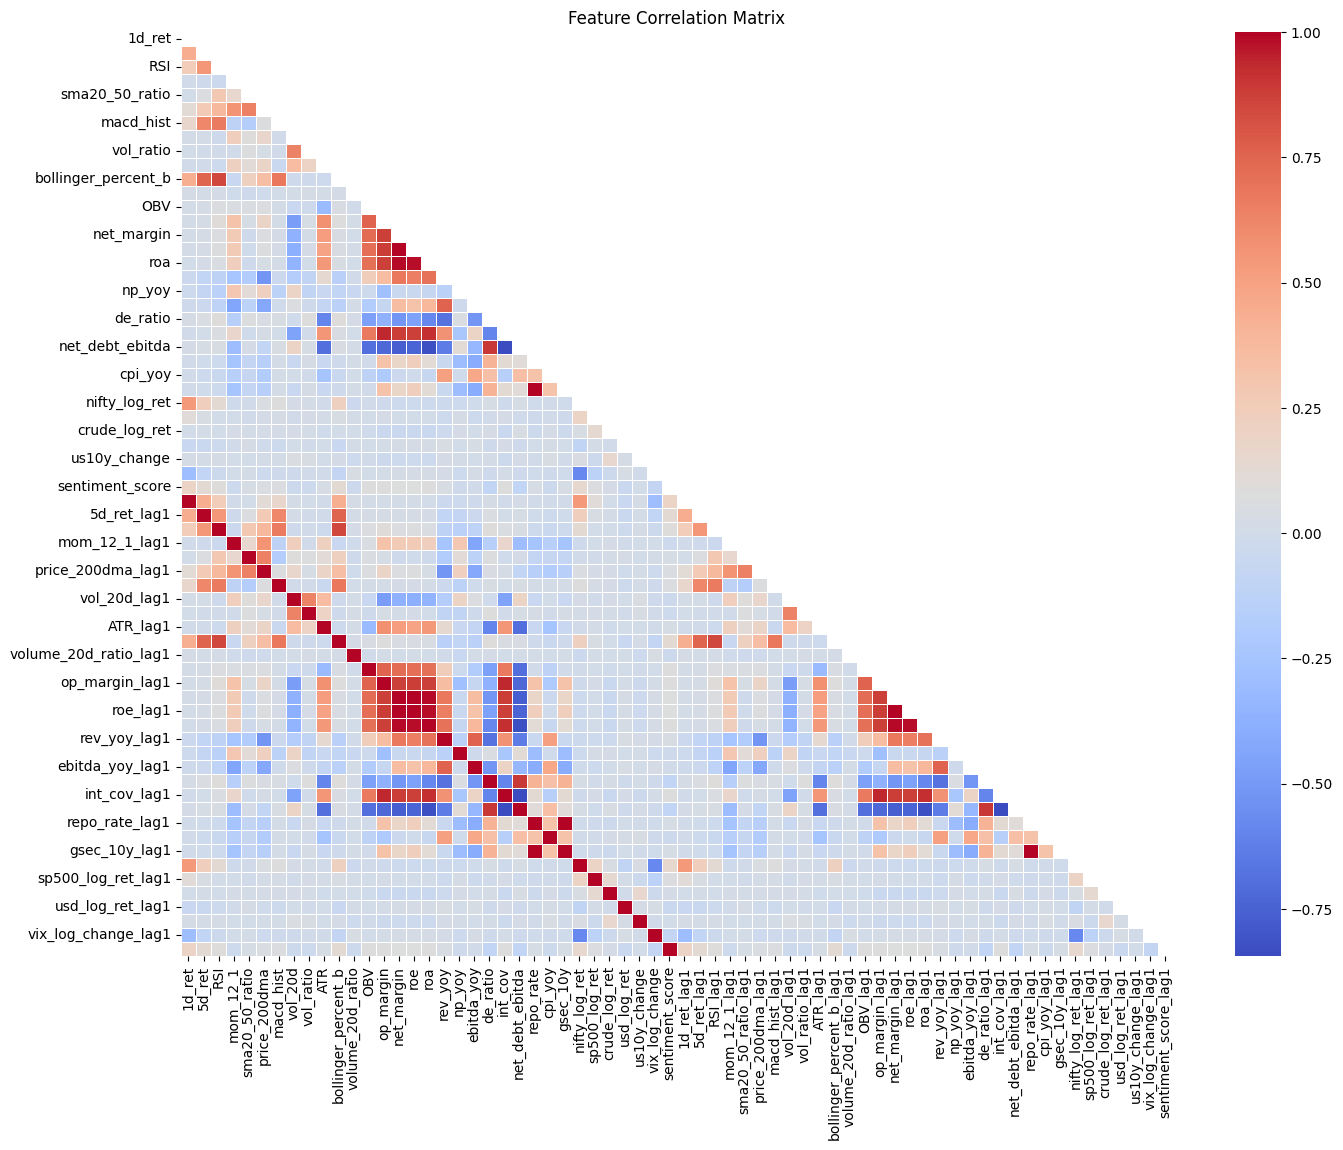

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.drop(columns=['Date', 'Ticker', 'target']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [60]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
final_features_df = importance[~importance['Feature'].isin(to_drop)]
top_final_features = final_features_df.head(12)['Feature'].tolist()
print(top_final_features)

Your Optimized Multi-Factor Feature Set:
['sp500_log_ret_lag1', 'sentiment_score_lag1', 'repo_rate_lag1', 'nifty_log_ret_lag1', 'usd_log_ret_lag1', 'crude_log_ret_lag1', 'vix_log_change_lag1', 'us10y_change_lag1', 'cpi_yoy_lag1', 'net_debt_ebitda_lag1', 'OBV_lag1', 'vol_20d_lag1']


In [61]:
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler

df_clean = df_model.copy()

# --- 1. WINSORIZATION ---
for col in top_final_features:
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])

# --- 2. INTERACTION FEATURES ---
df_clean['sent_mom_interaction'] = df_clean['sentiment_score_lag1'] * df_clean['1d_ret_lag1']
final_modeling_features = top_final_features + ['sent_mom_interaction']

# --- 3. ROLLING STANDARDIZATION (Z-Scores) ---
for col in final_modeling_features:
    if col in df_clean.columns:
        df_clean[f'{col}_z'] = df_clean.groupby('Ticker')[col].transform(
            lambda x: (x - x.rolling(30).mean()) / x.rolling(30).std()
        )
    else:
        print(f"Warning: Column '{col}' not found in df_clean for rolling standardization.")

# --- 4. TRAIN-TEST SPLIT ---
test_cutoff = df_clean['Date'].max() - pd.Timedelta(days=90)
train_df = df_clean[df_clean['Date'] < test_cutoff].copy()
test_df = df_clean[df_clean['Date'] >= test_cutoff].copy()

print(f"Training rows: {len(train_df)}")
print(f"Portfolio Test rows (3 months): {len(test_df)}")

Training rows: 7044
Portfolio Test rows (3 months): 366


In [62]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

z_features = [col for col in train_df.columns if col.endswith('_z')]

X_train = train_df[z_features]
y_train = train_df['target']
X_test = test_df[z_features]
y_test = test_df['target']

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
test_df['pred_return'] = model.predict(X_test)

In [63]:
portfolio_df = test_df.pivot(index='Date', columns='Ticker', values='pred_return')
actual_returns_df = test_df.pivot(index='Date', columns='Ticker', values='target')

def get_weights(row):
    top_3 = row.nlargest(3).index
    weights = pd.Series(0, index=row.index)
    weights[top_3] = 1/3
    return weights

weights_df = portfolio_df.apply(get_weights, axis=1)


portfolio_returns = (weights_df * actual_returns_df).sum(axis=1)
cumulative_returns = (1 + portfolio_returns).cumprod() - 1

/tmp/ipython-input-2023164897.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[top_3] = 1/3
/tmp/ipython-input-2023164897.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[top_3] = 1/3
/tmp/ipython-input-2023164897.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[top_3] = 1/3
/tmp/ipython-input-2023164897.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will

In [64]:
total_return = cumulative_returns.iloc[-1]
daily_avg = portfolio_returns.mean()
daily_std = portfolio_returns.std()
sharpe = (daily_avg / daily_std) * np.sqrt(252) # Annualized

print(f"--- 3-Month Portfolio Report ---")
print(f"Total Portfolio Return: {total_return:.2%}")
print(f"Annualized Sharpe Ratio: {sharpe:.2f}")
print(f"Best Performing Day: {portfolio_returns.max():.2%}")

--- 3-Month Portfolio Report ---
Total Portfolio Return: 15.74%
Annualized Sharpe Ratio: 6.37
Best Performing Day: 1.89%


In [65]:
correlation = test_df[['pred_return', 'target']].corr().iloc[0,1]
print(f"Prediction-Reality Correlation: {correlation:.4f}")
if correlation > 0.20:
    print("WARNING: Correlation is suspiciously high. Check your .shift(-1) logic!")
benchmark_returns = actual_returns_df.mean(axis=1)
benchmark_sharpe = (benchmark_returns.mean() / benchmark_returns.std()) * np.sqrt(252)
print(f"Benchmark Sharpe (Buy & Hold): {benchmark_sharpe:.2f}")

Prediction-Reality Correlation: 0.1837
Benchmark Sharpe (Buy & Hold): 3.30


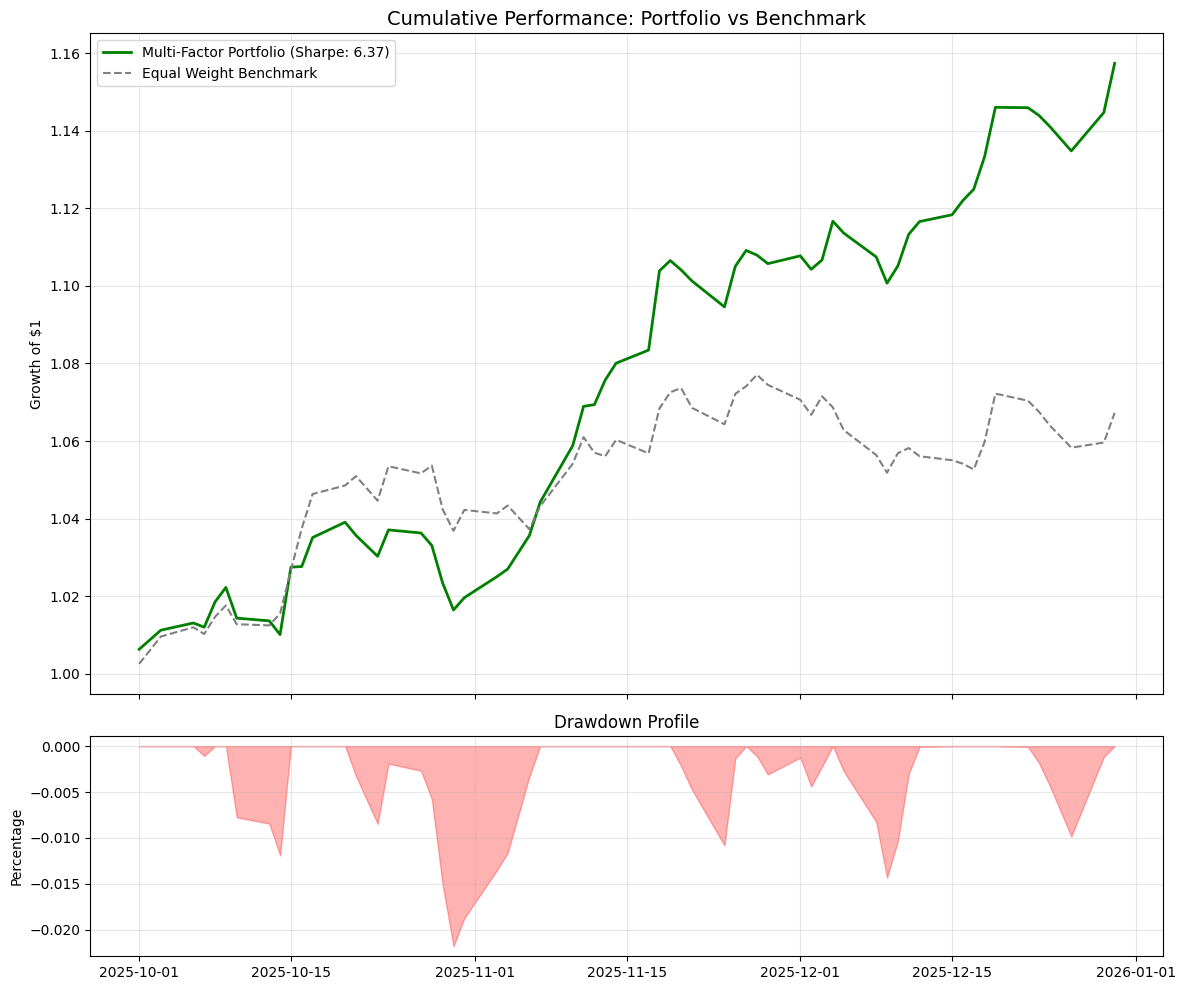

------------------------------
   PORTFOLIO PERFORMANCE REPORT   
------------------------------
Total 3-Month Return:  15.74%
Benchmark Return:      6.73%
Annualized Sharpe:     6.37
Maximum Drawdown:      -2.18%
Hit Ratio (Direction): 73.77%
------------------------------


In [66]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCULATE METRICS
# Equity Curve
equity_curve = (1 + portfolio_returns).cumprod()
benchmark_curve = (1 + benchmark_returns).cumprod()

# Hit Ratio (Directional Accuracy)
hit_ratio = (np.sign(portfolio_returns) == np.sign(benchmark_returns)).mean()

# Maximum Drawdown
rolling_max = equity_curve.cummax()
drawdown = (equity_curve - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Annualized Sharpe
sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252)

# 2. CREATE THE REPORTING DASHBOARD
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Equity Curve
ax1.plot(equity_curve, label=f'Multi-Factor Portfolio (Sharpe: {sharpe:.2f})', color='green', lw=2)
ax1.plot(benchmark_curve, label='Equal Weight Benchmark', color='gray', linestyle='--')
ax1.set_title('Cumulative Performance: Portfolio vs Benchmark', fontsize=14)
ax1.set_ylabel('Growth of $1')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Drawdown
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax2.set_title('Drawdown Profile', fontsize=12)
ax2.set_ylabel('Percentage')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. PRINT SUMMARY TABLE
print("-" * 30)
print("   PORTFOLIO PERFORMANCE REPORT   ")
print("-" * 30)
print(f"Total 3-Month Return:  {(equity_curve.iloc[-1] - 1):.2%}")
print(f"Benchmark Return:      {(benchmark_curve.iloc[-1] - 1):.2%}")
print(f"Annualized Sharpe:     {sharpe:.2f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")
print(f"Hit Ratio (Direction): {hit_ratio:.2%}")
print("-" * 30)

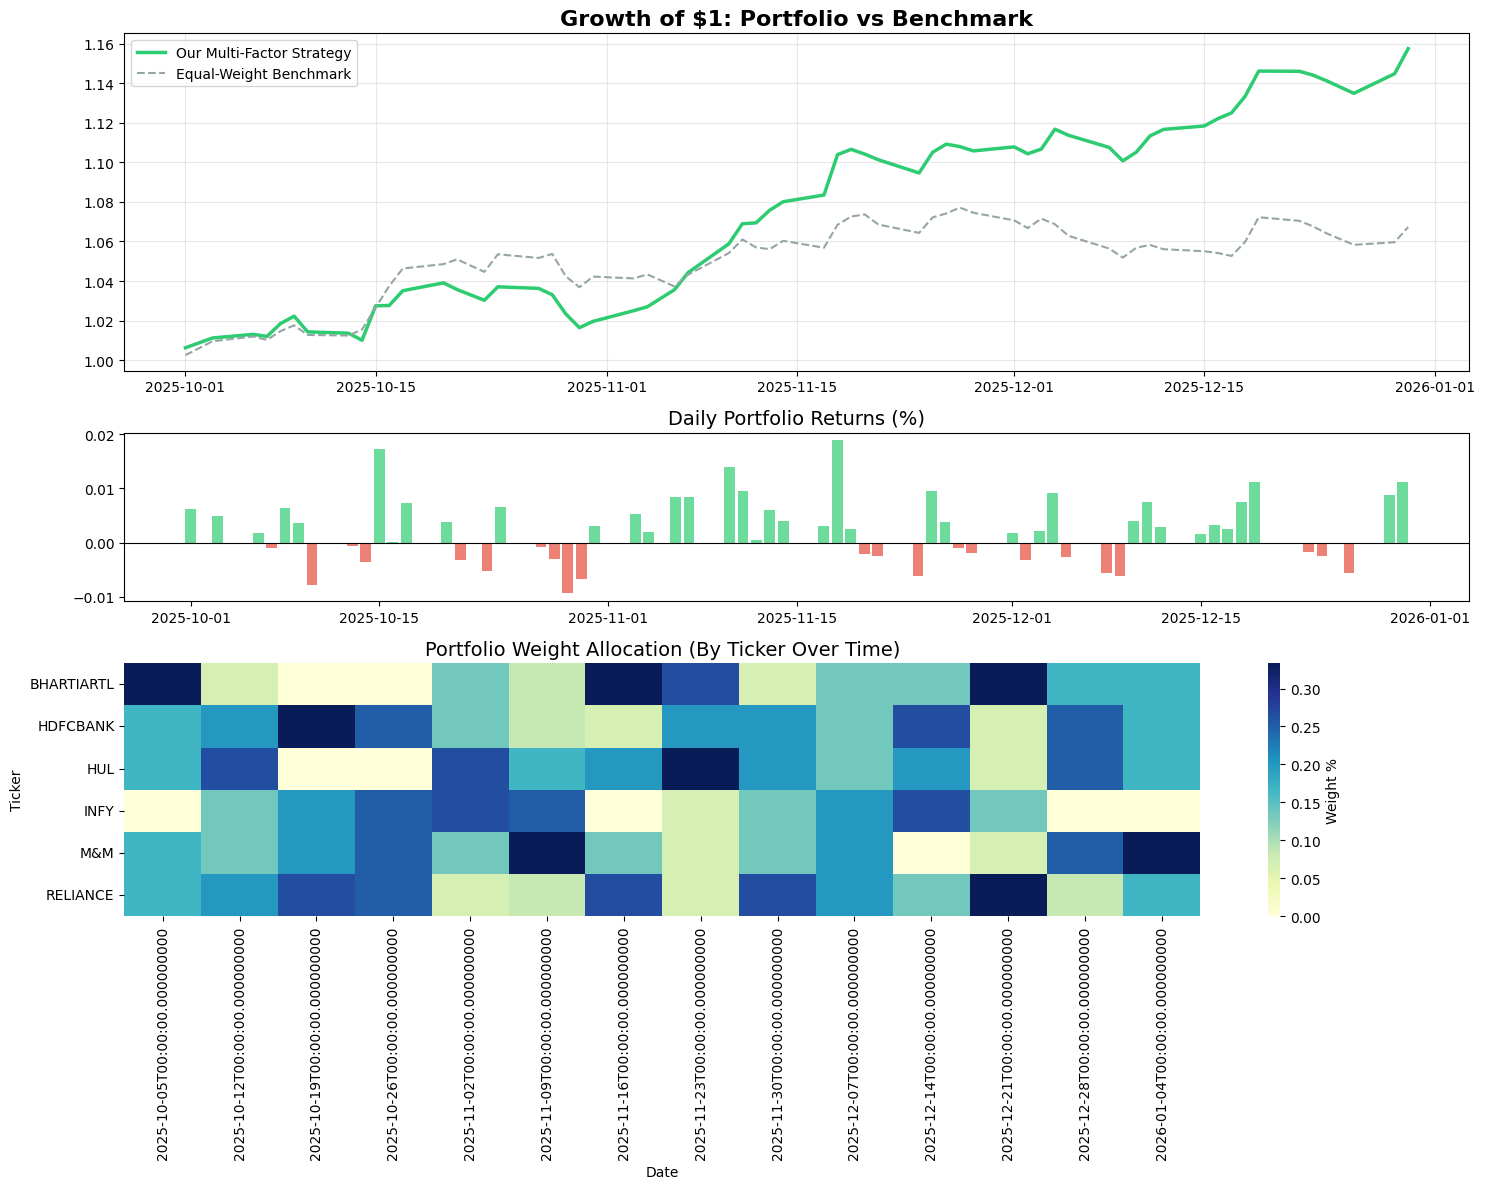

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 3 subplots
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1.5])

# Plot 1: Cumulative Returns (The Equity Curve)
ax1 = fig.add_subplot(gs[0])
ax1.plot(equity_curve.index, equity_curve, label='Our Multi-Factor Strategy', lw=2.5, color='#2ecc71')
ax1.plot(benchmark_curve.index, benchmark_curve, label='Equal-Weight Benchmark', lw=1.5, color='#95a5a6', linestyle='--')
ax1.set_title('Growth of $1: Portfolio vs Benchmark', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Plot 2: Daily Returns (The "Pulse" of the strategy)
ax2 = fig.add_subplot(gs[1])
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in portfolio_returns]
ax2.bar(portfolio_returns.index, portfolio_returns, color=colors, alpha=0.7)
ax2.set_title('Daily Portfolio Returns (%)', fontsize=14)
ax2.axhline(0, color='black', lw=0.8)

# Plot 3: Allocation Heatmap (Which stocks were chosen?)
ax3 = fig.add_subplot(gs[2])
# Show weights of each stock over time (resampled to weekly for clarity)
weekly_weights = weights_df.resample('W').mean()
sns.heatmap(weekly_weights.T, annot=False, cmap="YlGnBu", ax=ax3, cbar_kws={'label': 'Weight %'})
ax3.set_title('Portfolio Weight Allocation (By Ticker Over Time)', fontsize=14)

plt.tight_layout()
plt.show()

In [78]:
# 1. Active Returns & Tracking Error
active_returns = portfolio_returns - benchmark_returns
tracking_error = active_returns.std() * np.sqrt(252)
information_ratio = (active_returns.mean() * 252) / tracking_error

# 2. Sortino Ratio
downside_returns = portfolio_returns[portfolio_returns < 0]
sortino = (portfolio_returns.mean() * 252) / (downside_returns.std() * np.sqrt(252))

# 3. Maximum Adverse Excursion (MAE)
# This shows the worst potential loss during any single trade period
print(f"--- VALIDATION STATS ---")
print(f"Sortino Ratio: {sortino:.2f} (Focuses on Downside Risk)")
print(f"Information Ratio: {information_ratio:.2f} (Quality of Alpha)")
print(f"Tracking Error: {tracking_error:.2%}")

--- VALIDATION STATS ---
Sortino Ratio: 15.38 (Focuses on Downside Risk)
Information Ratio: 5.12 (Quality of Alpha)
Tracking Error: 6.58%


In [70]:
X_test_shuffled = X_test.sample(frac=1).reset_index(drop=True)
fake_preds = model.predict(X_test_shuffled)
fake_corr = np.corrcoef(fake_preds, y_test)[0, 1]
print(f"Correlation with Scrambled Data: {fake_corr:.4f}")

Correlation with Scrambled Data: -0.0745


In [71]:
from sklearn.metrics import r2_score

# Calculate R2 for existing XGBoost model
xgb_r2 = r2_score(y_test, test_df['pred_return'])

print(f"Your XGBoost Regressor R²: {xgb_r2:.4f}")

Your XGBoost Regressor R²: 0.0224


In [72]:
# General Accuracy
actual_dir = np.sign(y_test)
pred_dir = np.sign(test_df['pred_return'])

accuracy = (actual_dir == pred_dir).mean()

# High-Confidence Accuracy (Top 20%):
threshold = test_df['pred_return'].abs().quantile(0.80)
high_conf_df = test_df[test_df['pred_return'].abs() >= threshold]

high_conf_acc = (np.sign(high_conf_df['target']) == np.sign(high_conf_df['pred_return'])).mean()

print(f"Your Classifier Accuracy: {accuracy:.1%}")
print(f"Your High-Confidence Accuracy (Top 20%): {high_conf_acc:.1%}")

Your Classifier Accuracy: 56.0%
Your High-Confidence Accuracy (Top 20%): 58.1%


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, test_df['pred_return'])
rmse = np.sqrt(mean_squared_error(y_test, test_df['pred_return']))
r2 = r2_score(y_test, test_df['pred_return'])

print(f"MAE: {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R-Squared: {r2:.5f}")

MAE: 0.00785
RMSE: 0.01048
R-Squared: 0.02245
